# PTM literature and source landscape

For **human phospho** rows in `ptm.txt` that overlap measured sites, summarizes **PMID multiplicity** and **source** × **ptm_type** counts (restricted to proteins in `data.tsv`).

**Inputs:** `data.tsv`, `data/ptm.txt`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402
import ptm_data as ptm  # noqa: E402

DATA_PATH = ROOT / "data.tsv"
PTM_PATH = ROOT / "data" / "ptm.txt"
PPIC_PATH = ROOT / "data" / "ppic" / "edges.tsv"
KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"

THR = float(-np.log10(0.05))
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 40)

print("ROOT =", ROOT)


ROOT = /Users/ph/Documents/phospho_mhg_anno


In [2]:
DATA = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df_ptm = ptm.load_ptm(PTM_PATH)
df_phos = ptm.add_site_key_ptm(ptm.filter_human(ptm.filter_ptm_type(df_ptm, 'PHOSPHORYLATION')))
data_sk = ptm.add_site_key_phospho(DATA)
keys = set(data_sk['_site_key']) - {''}
ov = df_phos[df_phos['_site_key'].isin(keys)].copy()
ov['_n_pmids'] = ov['pmid'].apply(ptm.n_pmids)
print('Overlapping phospho PTM rows:', len(ov))


Overlapping phospho PTM rows: 2171


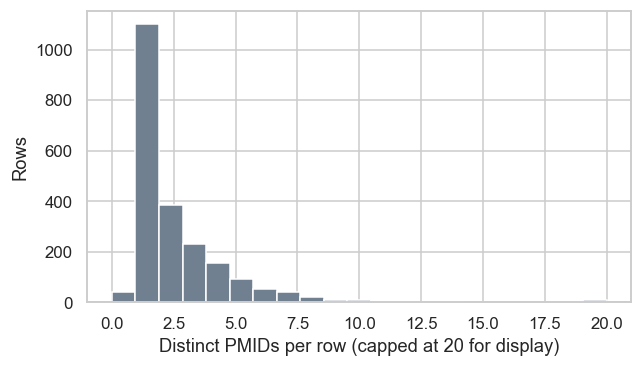

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ov['_n_pmids'].clip(upper=20).hist(bins=21, ax=ax, color='slategray')
ax.set_xlabel('Distinct PMIDs per row (capped at 20 for display)')
ax.set_ylabel('Rows')
fig.tight_layout()
plt.show()


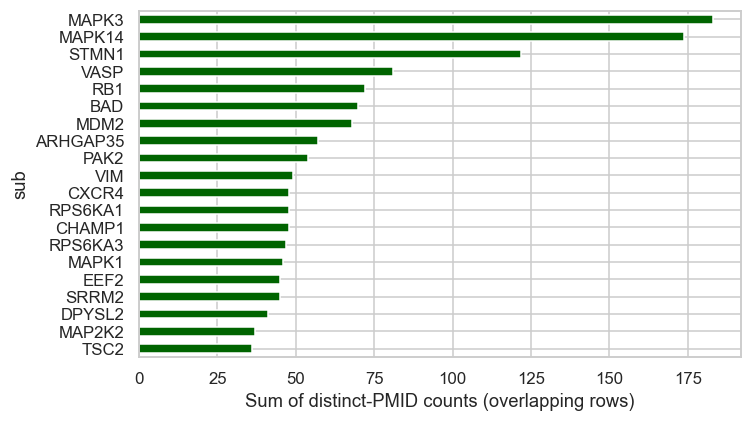

In [4]:
by_gene = (
    ov.assign(sub=ov['substrate_genename'].astype(str).str.upper())
    .groupby('sub')['_n_pmids']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(7, 4))
by_gene.sort_values().plot(kind='barh', ax=ax, color='darkgreen')
ax.set_xlabel('Sum of distinct-PMID counts (overlapping rows)')
fig.tight_layout()
plt.show()


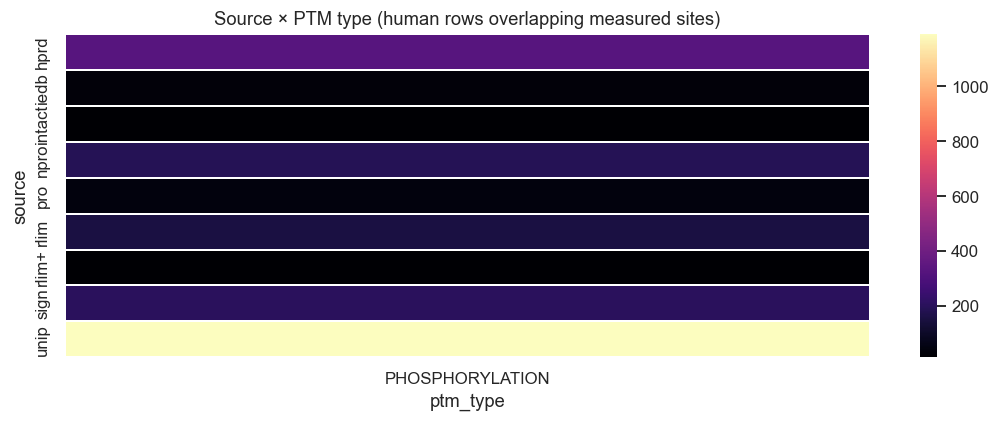

In [5]:
ct = pd.crosstab(ov['source'].astype(str), ov['ptm_type'].astype(str))
fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * len(ct))))
sns.heatmap(ct, ax=ax, cmap='magma', linewidths=0.3)
ax.set_title('Source × PTM type (human rows overlapping measured sites)')
fig.tight_layout()
plt.show()
